# Phase 4: Applicability Domain, Visualization, and Final Metrics Integration

This notebook retrains the locked Champion Model (`Hierarchical_MC_MLR`) using the eight descriptors selected during Phase 3, generates publication-quality diagnostic figures, and consolidates all model metrics into a single master table.

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data" / "features").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_DIR = PROJECT_ROOT / "data" / "features"

TRAIN_PATH = DATA_DIR / "filtered_train_pyqsar3.csv"
TEST_PATH = DATA_DIR / "filtered_test_pyqsar3.csv"
MCCV_SUMMARY_PATH = DATA_DIR / "mccv_summary.json"
LINEAR_METRICS_PATH = DATA_DIR / "12_model_extended_metrics.csv"
NONLINEAR_METRICS_PATH = DATA_DIR / "nonlinear_model_metrics.csv"
YSCRAMBLING_SUMMARY_PATH = DATA_DIR / "yscrambling_summary.json"

PRED_FIG_PATH = DATA_DIR / "figure_predicted_vs_experimental.png"
WILLIAMS_FIG_PATH = DATA_DIR / "figure_williams_plot.png"
MASTER_METRICS_PATH = DATA_DIR / "final_comprehensive_metrics.csv"

for path in [
    TRAIN_PATH,
    TEST_PATH,
    MCCV_SUMMARY_PATH,
    LINEAR_METRICS_PATH,
    NONLINEAR_METRICS_PATH,
    YSCRAMBLING_SUMMARY_PATH,
]:
    if not path.exists():
        raise FileNotFoundError(f"Required input file is missing: {path}")

## 1. Champion Model Retraining

The Champion Model is retrained as a multiple linear regression model using only the locked eight descriptors recorded in `mccv_summary.json`.

In [2]:
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

with MCCV_SUMMARY_PATH.open("r", encoding="utf-8") as handle:
    mccv_summary = json.load(handle)

with YSCRAMBLING_SUMMARY_PATH.open("r", encoding="utf-8") as handle:
    yscrambling_summary = json.load(handle)

champion_model = mccv_summary.get("champion_model", "Hierarchical_MC_MLR")
champion_algorithm = mccv_summary.get("algorithm", "MLR")
champion_features = mccv_summary["features"]

if champion_model != "Hierarchical_MC_MLR":
    raise ValueError(f"Unexpected champion model in MCCV summary: {champion_model}")
if champion_algorithm != "MLR":
    raise ValueError(f"Unexpected champion algorithm in MCCV summary: {champion_algorithm}")
if len(champion_features) != 8:
    raise ValueError(f"Expected exactly 8 champion descriptors, found {len(champion_features)}")

missing_train = sorted(set(champion_features) - set(train_df.columns))
missing_test = sorted(set(champion_features) - set(test_df.columns))
if missing_train or missing_test:
    raise ValueError(f"Champion descriptors missing. Train: {missing_train}; Test: {missing_test}")

X_train = train_df[champion_features].to_numpy(dtype=float)
y_train = train_df["logKoc"].to_numpy(dtype=float)
X_test = test_df[champion_features].to_numpy(dtype=float)
y_test = test_df["logKoc"].to_numpy(dtype=float)

model = LinearRegression()
model.fit(X_train, y_train)

train_pred = model.predict(X_train)
test_pred = model.predict(X_test)


def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

train_r2 = float(r2_score(y_train, train_pred))
test_r2 = float(r2_score(y_test, test_pred))
train_rmse = rmse(y_train, train_pred)
test_rmse = rmse(y_test, test_pred)
train_mae = float(mean_absolute_error(y_train, train_pred))
test_mae = float(mean_absolute_error(y_test, test_pred))

print(f"Champion model: {champion_model} ({champion_algorithm})")
print(f"Champion descriptors ({len(champion_features)}): {champion_features}")
print(f"Train: R2={train_r2:.4f}, RMSE={train_rmse:.4f}, MAE={train_mae:.4f}")
print(f"Test:  R2={test_r2:.4f}, RMSE={test_rmse:.4f}, MAE={test_mae:.4f}")

Champion model: Hierarchical_MC_MLR (MLR)
Champion descriptors (8): ['ABC', 'BCUTs-1h', 'C1SP2', 'ETA_shape_y', 'FilterItLogS', 'NdS', 'SlogP_VSA1', 'SlogP_VSA2']
Train: R2=0.8202, RMSE=0.5086, MAE=0.4108
Test:  R2=0.8143, RMSE=0.5101, MAE=0.3971


## 2. Figure 1: Predicted vs. Experimental logKoc

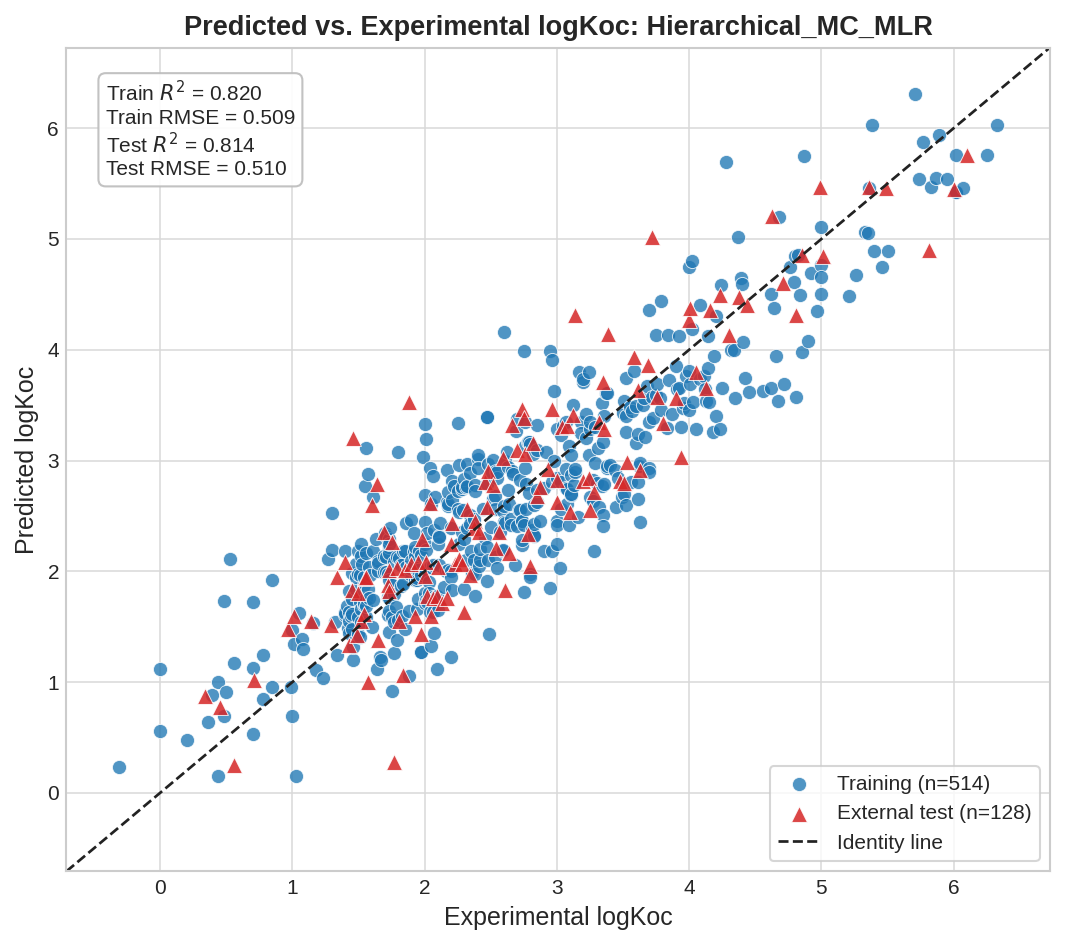

Saved predicted-vs-experimental figure to: /home/jun/Documents/qsar_modeling/data/features/figure_predicted_vs_experimental.png


In [3]:
plt.style.use("seaborn-v0_8-whitegrid")

all_exp = np.concatenate([y_train, y_test])
all_pred = np.concatenate([train_pred, test_pred])
plot_min = float(min(all_exp.min(), all_pred.min()))
plot_max = float(max(all_exp.max(), all_pred.max()))
padding = 0.06 * (plot_max - plot_min)
lims = (plot_min - padding, plot_max + padding)

fig, ax = plt.subplots(figsize=(7.2, 6.4), dpi=150)
ax.scatter(
    y_train,
    train_pred,
    s=46,
    alpha=0.78,
    c="#1f77b4",
    edgecolor="white",
    linewidth=0.45,
    label=f"Training (n={len(y_train)})",
)
ax.scatter(
    y_test,
    test_pred,
    s=58,
    alpha=0.86,
    marker="^",
    c="#d62728",
    edgecolor="white",
    linewidth=0.45,
    label=f"External test (n={len(y_test)})",
)
ax.plot(lims, lims, color="#222222", linestyle="--", linewidth=1.3, label="Identity line")

metrics_text = (
    f"Train $R^2$ = {train_r2:.3f}\n"
    f"Train RMSE = {train_rmse:.3f}\n"
    f"Test $R^2$ = {test_r2:.3f}\n"
    f"Test RMSE = {test_rmse:.3f}"
)
ax.text(
    0.04,
    0.96,
    metrics_text,
    transform=ax.transAxes,
    va="top",
    ha="left",
    fontsize=10,
    bbox={"boxstyle": "round,pad=0.35", "facecolor": "white", "edgecolor": "#bdbdbd", "alpha": 0.92},
)

ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel("Experimental logKoc", fontsize=12)
ax.set_ylabel("Predicted logKoc", fontsize=12)
ax.set_title("Predicted vs. Experimental logKoc: Hierarchical_MC_MLR", fontsize=13, weight="bold")
ax.legend(frameon=True, loc="lower right")
ax.grid(True, color="#d9d9d9", linewidth=0.75)
fig.tight_layout()
fig.savefig(PRED_FIG_PATH, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved predicted-vs-experimental figure to: {PRED_FIG_PATH}")

## 3. Figure 2: Williams Plot for Applicability Domain

Leverage values are calculated from the training design matrix. Standardized residuals use the training residual standard error, and the warning leverage threshold is defined as `h* = 3(p + 1) / n`.

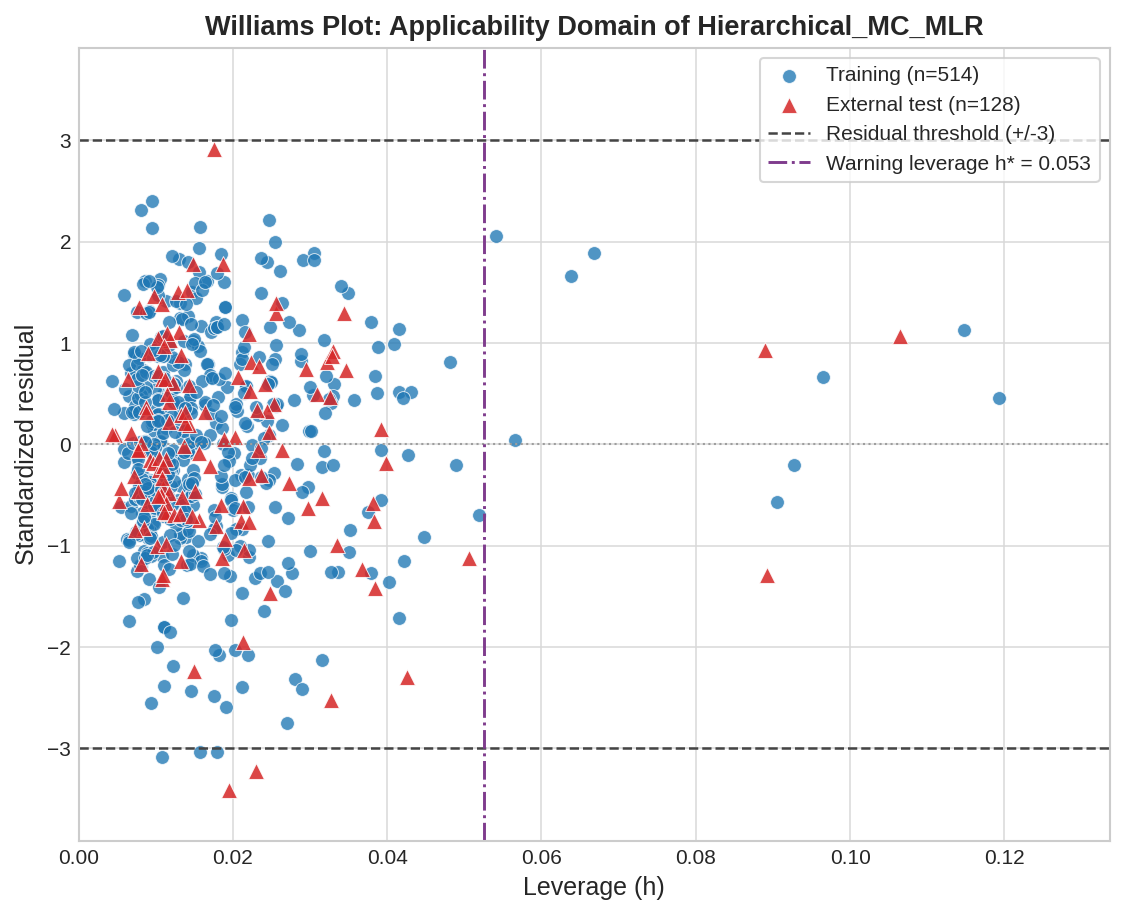

Saved Williams Plot to: /home/jun/Documents/qsar_modeling/data/features/figure_williams_plot.png
Warning leverage h*: 0.052529
Training leverage range: 0.004350 to 0.119355
Test leverage range: 0.004340 to 0.106497
Training standardized residual range: -3.084 to 2.406
Test standardized residual range: -3.406 to 2.914


In [4]:
def design_matrix(values):
    return np.column_stack([np.ones(values.shape[0]), values])

p = len(champion_features)
n_train = X_train.shape[0]

X_design_train = design_matrix(X_train)
X_design_test = design_matrix(X_test)
xtx_inv = np.linalg.pinv(X_design_train.T @ X_design_train)

train_leverage = np.einsum("ij,jk,ik->i", X_design_train, xtx_inv, X_design_train)
test_leverage = np.einsum("ij,jk,ik->i", X_design_test, xtx_inv, X_design_test)
h_star = 3 * (p + 1) / n_train

train_residuals = y_train - train_pred
test_residuals = y_test - test_pred
residual_se = np.sqrt(np.sum(train_residuals ** 2) / (n_train - p - 1))

if residual_se <= 0:
    raise ValueError("Training residual standard error must be positive for standardized residuals.")

train_std_residuals = train_residuals / residual_se
test_std_residuals = test_residuals / residual_se

max_h = float(max(train_leverage.max(), test_leverage.max(), h_star))
xmax = max_h * 1.12

fig, ax = plt.subplots(figsize=(7.6, 6.2), dpi=150)
ax.scatter(
    train_leverage,
    train_std_residuals,
    s=44,
    alpha=0.78,
    c="#1f77b4",
    edgecolor="white",
    linewidth=0.45,
    label=f"Training (n={len(y_train)})",
)
ax.scatter(
    test_leverage,
    test_std_residuals,
    s=58,
    alpha=0.86,
    marker="^",
    c="#d62728",
    edgecolor="white",
    linewidth=0.45,
    label=f"External test (n={len(y_test)})",
)

ax.axhline(3, color="#444444", linestyle="--", linewidth=1.2, label="Residual threshold (+/-3)")
ax.axhline(-3, color="#444444", linestyle="--", linewidth=1.2)
ax.axhline(0, color="#9e9e9e", linestyle=":", linewidth=1.0)
ax.axvline(h_star, color="#7f3c8d", linestyle="-.", linewidth=1.4, label=f"Warning leverage h* = {h_star:.3f}")

all_std = np.concatenate([train_std_residuals, test_std_residuals])
y_abs = max(3.3, float(np.nanmax(np.abs(all_std))) * 1.15)
ax.set_xlim(0, xmax)
ax.set_ylim(-y_abs, y_abs)
ax.set_xlabel("Leverage (h)", fontsize=12)
ax.set_ylabel("Standardized residual", fontsize=12)
ax.set_title("Williams Plot: Applicability Domain of Hierarchical_MC_MLR", fontsize=13, weight="bold")
ax.legend(frameon=True, loc="best")
ax.grid(True, color="#d9d9d9", linewidth=0.75)
fig.tight_layout()
fig.savefig(WILLIAMS_FIG_PATH, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved Williams Plot to: {WILLIAMS_FIG_PATH}")
print(f"Warning leverage h*: {h_star:.6f}")
print(f"Training leverage range: {train_leverage.min():.6f} to {train_leverage.max():.6f}")
print(f"Test leverage range: {test_leverage.min():.6f} to {test_leverage.max():.6f}")
print(f"Training standardized residual range: {train_std_residuals.min():.3f} to {train_std_residuals.max():.3f}")
print(f"Test standardized residual range: {test_std_residuals.min():.3f} to {test_std_residuals.max():.3f}")

## 4. Master Metrics Integration

The 12 linear baseline records and 4 non-linear records are normalized into one 16-model master table. MCCV and Y-scrambling statistics are appended only to the Champion Model row.

In [5]:
linear_metrics = pd.read_csv(LINEAR_METRICS_PATH)
nonlinear_metrics = pd.read_csv(NONLINEAR_METRICS_PATH)

metric_cols = [
    "R2_train",
    "CCC_tr",
    "RMSE_train",
    "Q2_cv",
    "CCC_cv",
    "RMSE_cv",
    "MAE_cv",
    "Q2_ext_F1",
    "Q2_ext_F2",
    "Q2_ext_F3",
    "CCC_ext",
    "RMSE_ext",
    "MAE_ext",
]

linear_master = linear_metrics.copy()
linear_master["Model_Family"] = "Linear"
linear_master["Best_Params"] = "{}"

nonlinear_master = nonlinear_metrics.rename(
    columns={
        "model": "Model_ID",
        "selector": "Selector",
        "model_type": "Regressor",
        "n_features": "N_Selected_Features",
        "selected_features": "Selected_Features",
        "best_params": "Best_Params",
    }
).copy()
nonlinear_master["Model_Family"] = "Nonlinear"
nonlinear_master["Track"] = nonlinear_master["Model_ID"].str.split("_").str[0]
nonlinear_master["Cluster_File"] = "feature_clusters_pyqsar3_hierarchical.cluster"

base_cols = [
    "Model_ID",
    "Model_Family",
    "Track",
    "Selector",
    "Regressor",
    "Cluster_File",
    "N_Selected_Features",
    "Selected_Features",
    "Best_Params",
]

for frame_name, frame in [("linear", linear_master), ("nonlinear", nonlinear_master)]:
    missing = sorted(set(base_cols + metric_cols) - set(frame.columns))
    if missing:
        raise ValueError(f"Missing columns in {frame_name} metrics: {missing}")

master_metrics = pd.concat(
    [linear_master[base_cols + metric_cols], nonlinear_master[base_cols + metric_cols]],
    ignore_index=True,
)

mccv_metrics = mccv_summary.get("mccv", {}).get("metrics", {})
master_metrics["MCCV_R2_ext_Mean"] = np.nan
master_metrics["MCCV_R2_ext_SD"] = np.nan
master_metrics["MCCV_RMSE_ext_Mean"] = np.nan
master_metrics["MCCV_RMSE_ext_SD"] = np.nan
master_metrics["MCCV_MAE_ext_Mean"] = np.nan
master_metrics["MCCV_MAE_ext_SD"] = np.nan
master_metrics["Y_Scramble_R2_Mean"] = np.nan
master_metrics["Y_Scramble_R2_SD"] = np.nan
master_metrics["Y_Scramble_R2_Max"] = np.nan
master_metrics["Champion_Features_Locked"] = ""

champion_mask = master_metrics["Model_ID"].eq(champion_model)
if champion_mask.sum() != 1:
    raise ValueError(f"Expected exactly one champion row for {champion_model}; found {champion_mask.sum()}")

master_metrics.loc[champion_mask, "MCCV_R2_ext_Mean"] = mccv_metrics["R2_ext"]["mean"]
master_metrics.loc[champion_mask, "MCCV_R2_ext_SD"] = mccv_metrics["R2_ext"]["sd"]
master_metrics.loc[champion_mask, "MCCV_RMSE_ext_Mean"] = mccv_metrics["RMSE_ext"]["mean"]
master_metrics.loc[champion_mask, "MCCV_RMSE_ext_SD"] = mccv_metrics["RMSE_ext"]["sd"]
master_metrics.loc[champion_mask, "MCCV_MAE_ext_Mean"] = mccv_metrics["MAE_ext"]["mean"]
master_metrics.loc[champion_mask, "MCCV_MAE_ext_SD"] = mccv_metrics["MAE_ext"]["sd"]
master_metrics.loc[champion_mask, "Y_Scramble_R2_Mean"] = yscrambling_summary["average_R2_y_sc"]
master_metrics.loc[champion_mask, "Y_Scramble_R2_SD"] = yscrambling_summary["sd_R2_y_sc"]
master_metrics.loc[champion_mask, "Y_Scramble_R2_Max"] = yscrambling_summary["max_R2_y_sc"]
master_metrics.loc[champion_mask, "Champion_Features_Locked"] = ";".join(champion_features)

master_metrics = master_metrics.sort_values(
    by=["Q2_cv", "Q2_ext_F2", "R2_train"],
    ascending=[False, False, False],
).reset_index(drop=True)
master_metrics.insert(0, "Rank_By_Q2_cv", np.arange(1, len(master_metrics) + 1))

master_metrics.to_csv(MASTER_METRICS_PATH, index=False)

display(master_metrics)
print(f"Saved comprehensive 16-model metrics table to: {MASTER_METRICS_PATH}")
print(f"Master table shape: {master_metrics.shape}")

,Rank_By_Q2_cv,Model_ID,Model_Family,Track,Selector,Regressor,Cluster_File,N_Selected_Features,Selected_Features,Best_Params,R2_train,CCC_tr,RMSE_train,Q2_cv,CCC_cv,RMSE_cv,MAE_cv,Q2_ext_F1,Q2_ext_F2,Q2_ext_F3,CCC_ext,RMSE_ext,MAE_ext,MCCV_R2_ext_Mean,MCCV_R2_ext_SD,MCCV_RMSE_ext_Mean,MCCV_RMSE_ext_SD,MCCV_MAE_ext_Mean,MCCV_MAE_ext_SD,Y_Scramble_R2_Mean,Y_Scramble_R2_SD,Y_Scramble_R2_Max,Champion_Features_Locked
0,1,Hierarchical_MC_MLR,Linear,Hierarchical,MC,MLR,feature_clusters_pyqsar3_hierarchical.cluster,8,ABC;BCUTs-1h;C1SP2;ETA_shape_y;FilterItLogS;Nd...,{},0.820182,0.901209,0.508648,0.811974,0.896656,0.520127,0.419998,0.814267,0.814252,0.819122,0.906043,0.510145,0.397140,0.806404,0.032097,0.518388,0.030136,0.418509,0.023859,0.016196,0.007508,0.039415,ABC;BCUTs-1h;C1SP2;ETA_shape_y;FilterItLogS;Nd...
1,2,Hierarchical_MC_PLS,Linear,Hierarchical,MC,PLS,feature_clusters_pyqsar3_hierarchical.cluster,8,ABC;BCUTs-1h;C1SP2;ETA_shape_y;FilterItLogS;Nd...,{},0.818294,0.900068,0.511312,0.811959,0.896633,0.520149,0.420112,0.816532,0.816517,0.821328,0.906940,0.507025,0.396826,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,
2,3,Hierarchical_GA_SVR,Nonlinear,Hierarchical,GA,SVR,feature_clusters_pyqsar3_hierarchical.cluster,8,"[""ATS1Z"", ""FilterItLogS"", ""GATS1i"", ""MIC0"", ""N...","{""model__C"": 10, ""model__gamma"": 0.01}",0.836797,0.913741,0.484580,0.811248,0.899660,0.521131,0.409097,0.809324,0.809308,0.814308,0.908156,0.516890,0.397865,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,
3,4,Hierarchical_GA_PLS,Linear,Hierarchical,GA,PLS,feature_clusters_pyqsar3_hierarchical.cluster,8,ABC;ATSC3s;BCUTs-1h;FilterItLogS;GATS1i;MATS1v...,{},0.816350,0.898890,0.514040,0.807286,0.894252,0.526572,0.417462,0.819976,0.819961,0.824682,0.909574,0.502244,0.405073,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,
4,5,Hierarchical_GA_MLR,Linear,Hierarchical,GA,MLR,feature_clusters_pyqsar3_hierarchical.cluster,8,ABC;ATSC3s;BCUTs-1h;FilterItLogS;GATS1i;MATS1v...,{},0.816775,0.899148,0.513444,0.807124,0.894196,0.526792,0.418151,0.819748,0.819733,0.824460,0.909900,0.502562,0.404386,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,
5,6,SOM_MC_MLR,Linear,SOM,MC,MLR,feature_clusters_pyqsar3_som.cluster,8,ABC;ATSC3s;BCUTs-1h;EState_VSA5;EState_VSA7;Fi...,{},0.815659,0.898472,0.515005,0.806598,0.893811,0.527511,0.410281,0.800784,0.800767,0.805991,0.899315,0.528338,0.406454,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,
6,7,SOM_MC_PLS,Linear,SOM,MC,PLS,feature_clusters_pyqsar3_som.cluster,8,ABC;ATSC2Z;ATSC3s;BCUTs-1h;EState_VSA5;FilterI...,{},0.815863,0.898595,0.514721,0.803669,0.892734,0.531490,0.414283,0.817486,0.817471,0.822257,0.908353,0.505706,0.382805,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,
7,8,SOM_GA_MLR,Linear,SOM,GA,MLR,feature_clusters_pyqsar3_som.cluster,8,AATS0dv;ATSC4Z;ATSC8dv;BCUTs-1h;EState_VSA5;Fi...,{},0.804537,0.891682,0.530314,0.796103,0.887085,0.541635,0.427792,0.779310,0.779292,0.785079,0.886501,0.556084,0.426606,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,
8,9,SOM_GA_PLS,Linear,SOM,GA,PLS,feature_clusters_pyqsar3_som.cluster,8,AATS0dv;ATSC4Z;ATSC8dv;BCUTs-1h;EState_VSA5;Fi...,{},0.803691,0.891162,0.531461,0.795522,0.886833,0.542406,0.428920,0.779388,0.779370,0.785155,0.886260,0.555986,0.427970,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,
9,10,Hierarchical_GA_RF,Nonlinear,Hierarchical,GA,RF,feature_clusters_pyqsar3_hierarchical.cluster,8,"[""AETA_eta"", ""BCUTd-1l"", ""BCUTdv-1h"", ""BCUTi-1...","{""model__max_depth"": 10, ""model__n_estimators""...",0.965689,0.981829,0.222186,0.794475,0.887611,0.543793,0.418373,0.825901,0.825886,0.830451,0.912035,0.493910,0.390374,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,


Saved comprehensive 16-model metrics table to: /home/jun/Documents/qsar_modeling/data/features/final_comprehensive_metrics.csv
Master table shape: (16, 33)


## 5. Output Check

In [6]:
for output_path in [PRED_FIG_PATH, WILLIAMS_FIG_PATH, MASTER_METRICS_PATH]:
    if not output_path.exists():
        raise FileNotFoundError(f"Expected output was not created: {output_path}")
    print(f"Created: {output_path} ({output_path.stat().st_size:,} bytes)")

Created: /home/jun/Documents/qsar_modeling/data/features/figure_predicted_vs_experimental.png (493,964 bytes)
Created: /home/jun/Documents/qsar_modeling/data/features/figure_williams_plot.png (442,984 bytes)
Created: /home/jun/Documents/qsar_modeling/data/features/final_comprehensive_metrics.csv (7,643 bytes)
